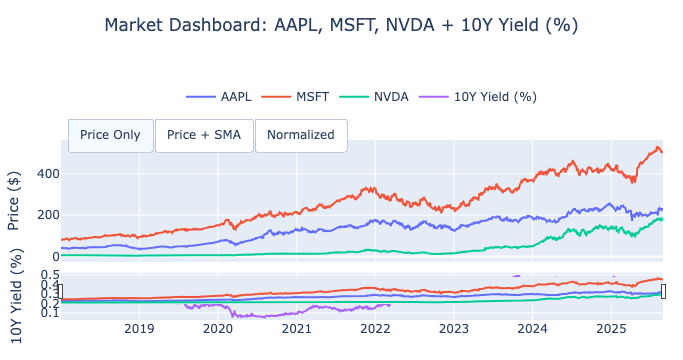

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import yfinance as yf

stocks = ["AAPL", "MSFT", "NVDA"]
macro  = "^TNX"        # or "^VIX", "^IRX"
start  = "2018-01-01"

data = yf.download(stocks + [macro], start=start, auto_adjust=True, progress=False)
close = data["Close"].copy().dropna()

#split stocks vs macro
present_stocks = [t for t in stocks if t in close.columns]
prices = close[present_stocks].dropna(how="all")

macro_series = close[macro].dropna()

# fixing macro units and label
if macro == "^TNX":              # 10Y Treasury yield
    macro_series = (macro_series / 10.0).rename("10Y Yield (%)")
elif macro == "^IRX":            # 13W T-bill (% already)
    macro_series = macro_series.rename("3M T-Bill (%)")
elif macro == "^VIX":            # Implied vol, unitless “points”
    macro_series = macro_series.rename("VIX (implied vol)")
else:
    macro_series = macro_series.rename(macro)

#Align dates
common_index = prices.index.intersection(macro_series.index)
prices       = prices.loc[common_index]
macro_series = macro_series.loc[common_index]

#Moving averages
sma20 = prices.rolling(20).mean().add_suffix(" SMA20")
sma50 = prices.rolling(50).mean().add_suffix(" SMA50")

#normalised series
prices_norm = prices.div(prices.iloc[0])     
macro_norm  = macro_series / macro_series.iloc[0]
macro_norm.name = macro_series.name + " (norm)"

#create rows
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    row_heights=[0.72, 0.28], vertical_spacing=0.06
)

raw_ids, sma_ids, norm_ids = [], [], []

# Row 1 — raw prices (visible by default)
for c in prices.columns:
    fig.add_trace(go.Scatter(x=prices.index, y=prices[c], name=c, mode="lines", visible=True), row=1, col=1)
    raw_ids.append(len(fig.data)-1)

# Row 1 — SMA20/SMA50 (start hidden)
for c in prices.columns:
    fig.add_trace(go.Scatter(x=sma20.index, y=sma20[c + " SMA20"], name=f"{c} SMA20", mode="lines", visible=False), row=1, col=1)
    sma_ids.append(len(fig.data)-1)
    fig.add_trace(go.Scatter(x=sma50.index, y=sma50[c + " SMA50"], name=f"{c} SMA50", mode="lines", visible=False), row=1, col=1)
    sma_ids.append(len(fig.data)-1)

# Row 1 — normalized prices (start hidden)
for c in prices_norm.columns:
    fig.add_trace(go.Scatter(x=prices_norm.index, y=prices_norm[c], name=f"{c} (norm)", mode="lines", visible=False), row=1, col=1)
    norm_ids.append(len(fig.data)-1)

# Row 2 — macro (raw + normalized; only raw visible at first)
fig.add_trace(go.Scatter(x=macro_series.index, y=macro_series, name=macro_series.name, mode="lines", visible=True), row=2, col=1)
macro_raw_id = len(fig.data)-1
fig.add_trace(go.Scatter(x=macro_norm.index,  y=macro_norm,  name=macro_norm.name,  mode="lines", visible=False), row=2, col=1)
macro_norm_id = len(fig.data)-1

# --- Build visibility masks for the buttons ---
n = len(fig.data)

visible_price_only = [False] * n
for i in raw_ids: visible_price_only[i] = True
visible_price_only[macro_raw_id] = True

visible_price_sma = [False] * n
for i in raw_ids: visible_price_sma[i] = True
for i in sma_ids: visible_price_sma[i] = True
visible_price_sma[macro_raw_id] = True

visible_normalized = [False] * n
for i in norm_ids: visible_normalized[i] = True
visible_normalized[macro_norm_id] = True

# 8) Buttons
fig.update_layout(
  updatemenus=[dict(
    type="buttons", x=0.01, y=1.12, xanchor="left", direction="right",
    buttons=[
      dict(label="Price Only",  method="update", args=[{"visible": visible_price_only}]),
      dict(label="Price + SMA", method="update", args=[{"visible": visible_price_sma}]),
      dict(label="Normalized",  method="update", args=[{"visible": visible_normalized}]),
    ],
    showactive=True
  )]
)

# Layout polish
fig.update_layout()


#Layout
fig.update_layout(
    title=f"Market Dashboard: {', '.join(present_stocks)} + {macro_series.name}",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.04, xanchor="left", x=0),
    margin=dict(l=40, r=20, t=80, b=40),
    xaxis=dict(rangeslider=dict(visible=True))  
)
fig.update_yaxes(title_text="Price ($)", row=1, col=1)
fig.update_yaxes(title_text=macro_series.name, row=2, col=1)

#Moving title up
fig.update_layout(
    margin=dict(l=40, r=20, t=140, b=40),  
    title=dict(
        text=f"Market Dashboard: {', '.join(present_stocks)} + {macro_series.name}",
        x=0.5, xanchor="center",          
        y=0.98, yanchor="top",           
        pad=dict(t=12)                    
    ),
    hovermode="x unified",
)

# put legend above the plot, centered
fig.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.16,   # ↑ higher than 1.0 = above plotting area
        xanchor="center", x=0.5
    )
)